In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Pavithra\Desktop\final project\data\extractive_summarization_results.csv")

df_dl = df[["clean_article", "clean_summary"]].dropna()

df_dl.rename(columns={
    "clean_article": "article",
    "clean_summary": "summary"
}, inplace=True)

In [2]:
print(df_dl.shape)
print(df_dl.head())

(113699, 2)
                                             article  \
0  only five internationals allowed, count em, fi...   
1  washington -- senate majority leader mitch mcc...   
2  north highlands cbs13 fire damaged a home in n...   
3  meghan mccain is speaking out after a journali...   
4  1714 george i becomes king georg ludwig, elect...   

                                             summary  
0  Predicting Atlanta United's lineup against Col...  
1  Mitch McConnell DC statehood push is 'full bor...  
2            Home In North Highlands Damaged By Fire  
3  Meghan McCain blames 'liberal media' and 'thir...  
4                             Today in History Aug 1  


In [3]:
df_dl = df_dl.sample(10000, random_state=42)
len(df_dl)

10000

In [4]:
# 2. Prepare text with <sos>/<eos>

df_dl["summary"] = df_dl["summary"].apply(lambda x: "sos " + x + " eos")



## Tokenization

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

src_tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
tgt_tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")

src_tokenizer.fit_on_texts(df_dl["article"])
tgt_tokenizer.fit_on_texts(df_dl["summary"])

## Convert to sequences

In [6]:
src_seq = src_tokenizer.texts_to_sequences(df_dl["article"])
tgt_seq = tgt_tokenizer.texts_to_sequences(df_dl["summary"])

## Padding

In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_src_len = 200
max_tgt_len = 50

encoder_input = pad_sequences(src_seq, maxlen=max_src_len, padding="post")
decoder_input = pad_sequences(tgt_seq, maxlen=max_tgt_len, padding="post")

## Create decoder target (shifted)

In [8]:
import numpy as np
decoder_target = np.zeros_like(decoder_input)

decoder_target[:, :-1] = decoder_input[:, 1:]

## Model Architecture

Basic Seq2Seq (LSTM)

In [9]:
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(max_src_len,))
enc_emb = Embedding(50000, 256)(encoder_inputs)
encoder_lstm = LSTM(256, return_state=True)
_, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(max_tgt_len,))
dec_emb = Embedding(20000, 128)(decoder_inputs)

decoder_lstm = LSTM(256, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = Dense(20000, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Model
lstm_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 256)  │ 12,800,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 128)   │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    525,312 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 50, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 20000) │  5,140,000 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,419,552 (81.71 MB)

 Trainable params: 21,419,552 (81.71 MB)

 Non-trainable params: 0 (0.00 B)

## MODEL 2: GRU SEQ2SEQ

In [10]:
from tensorflow.keras.layers import GRU

# Encoder
encoder_inputs2 = Input(shape=(max_src_len,))
enc_emb2 = Embedding(50000, 256)(encoder_inputs2)
encoder_gru = GRU(256, return_state=True)
_, state_h2 = encoder_gru(enc_emb2)

# Decoder
decoder_inputs2 = Input(shape=(max_tgt_len,))
dec_emb2 = Embedding(20000, 128)(decoder_inputs2)

decoder_gru = GRU(256, return_sequences=True, return_state=True)
decoder_outputs2, _ = decoder_gru(dec_emb2, initial_state=state_h2)

decoder_dense2 = Dense(20000, activation='softmax')
decoder_outputs2 = decoder_dense2(decoder_outputs2)

# Model
gru_model = Model([encoder_inputs2, decoder_inputs2], decoder_outputs2)
gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

## Training

In [11]:
# LSTM
lstm_model.fit(
    [encoder_input, decoder_input],
    decoder_target,
    batch_size=32,
    epochs=8,
    validation_split=0.1
)

# GRU
gru_model.fit(
    [encoder_input, decoder_input],
    decoder_target,
    batch_size=32,
    epochs=8,
    validation_split=0.1
)

Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - loss: 2.2316 - val_loss: 1.8019
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - loss: 1.7541 - val_loss: 1.7908
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - loss: 1.7165 - val_loss: 1.7852
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - loss: 1.6763 - val_loss: 1.7798
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - loss: 1.6306 - val_loss: 1.7720
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - loss: 1.5764 - val_loss: 1.7724
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - loss: 1.5178 - val_loss: 1.7798
Epoch 8/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - loss: 1.4597 - val_loss: 1.7914
Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - loss: 2.2494 - val_loss: 1.8027
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - loss: 1.7446 - val_loss: 1.7759
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - loss: 1.6765 - val_loss: 1.7642
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - 

In [12]:
# save the model
lstm_model.save(r"C:\Users\Pavithra\Desktop\final project\data\New folder\lstm_model.h5")
gru_model.save(r"C:\Users\Pavithra\Desktop\final project\data\New folder\gru_model.h5")


In [13]:
import pickle

file_path = r"C:\Users\Pavithra\Desktop\final project\data\New folder"

with open(f"{file_path}/src_tokenizer.pkl.pkl", "wb") as f:
    pickle.dump(src_tokenizer, f)
with open(f"{file_path}/tgt_tokenizer.pkl", "wb") as f:
    pickle.dump(tgt_tokenizer, f)
with open(f"{file_path}/config.pkl", "wb") as f:
    pickle.dump((max_src_len, max_tgt_len), f)

## Inference (generate summary)

You’ll need:

Encoder model
Decoder model

In [14]:
def generate_summary(text, model):

    seq = src_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_src_len, padding='post')

    reverse_tgt = {v:k for k,v in tgt_tokenizer.word_index.items()}

    start_token = tgt_tokenizer.word_index["sos"]
    end_token = tgt_tokenizer.word_index["eos"]

    decoder_input = np.zeros((1, max_tgt_len))
    decoder_input[0, 0] = start_token

    output = []

    for i in range(1, max_tgt_len):

        pred = model.predict([seq, decoder_input], verbose=0)
        token = np.argmax(pred[0, i-1, :])

        if token == end_token:
            break

        word = reverse_tgt.get(token, "")

        if word not in ["", "<OOV>", "<sos>"]:
            output.append(word)

        decoder_input[0, i] = token

    return " ".join(output)

In [15]:
print(list(tgt_tokenizer.word_index.keys())[:20])

['<OOV>', 'sos', 'eos', 'to', 'the', 'in', 'of', 'for', 'a', 'and', 'on', 'with', 'at', 'is', 'after', '2019', 'new', 'you', 'from', 'this']


## GENERATE SUMMARIES

In [16]:
from tqdm import tqdm
tqdm.pandas()

df_dl["lstm_summary"] = df_dl["article"].progress_apply(lambda x: generate_summary(x, lstm_model))
df_dl["gru_summary"] = df_dl["article"].progress_apply(lambda x: generate_summary(x, gru_model))

100%|██████████| 10000/10000 [4:09:45<00:00,  1.50s/it] 


## Evaluation

In [22]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1','rouge2','rougeL'],
    use_stemmer=True
)

def evaluate_model(df, col):

    scores = {"rouge1": [], "rouge2": [], "rougeL": []}

    for i in range(len(df)):

        ref = df["summary"].iloc[i]
        pred = df[col].iloc[i]

        # ✅ Skip invalid rows
        if not isinstance(ref, str) or not isinstance(pred, str):
            continue
        if len(ref.strip()) == 0 or len(pred.strip()) == 0:
            continue

        result = scorer.score(ref, pred)

        scores["rouge1"].append(result["rouge1"].fmeasure)
        scores["rouge2"].append(result["rouge2"].fmeasure)
        scores["rougeL"].append(result["rougeL"].fmeasure)

    return {
        "ROUGE-1": sum(scores["rouge1"]) / len(scores["rouge1"]) if scores["rouge1"] else 0,
        "ROUGE-2": sum(scores["rouge2"]) / len(scores["rouge2"]) if scores["rouge2"] else 0,
        "ROUGE-L": sum(scores["rougeL"]) / len(scores["rougeL"]) if scores["rougeL"] else 0
    }

In [23]:
results = {
    "LSTM": evaluate_model(df_dl, "lstm_summary"),
    "GRU": evaluate_model(df_dl, "gru_summary")
}

import pandas as pd
results_df = pd.DataFrame(results).T

print(results_df)

       ROUGE-1   ROUGE-2   ROUGE-L
LSTM  0.043563  0.003649  0.042129
GRU   0.076383  0.012178  0.072271


In [18]:
df_dl[["article", "summary", "lstm_summary", "gru_summary"]].to_csv(
    "dl_summaries.csv", index=False
)

In [24]:
results_df.to_csv("dl_evaluation_results.csv")

In [28]:
print(df_dl["lstm_summary"].head())
print(df_dl["gru_summary"].head())

47378                 the best best spots in the best
26099                             the best best stock
83843    trump says the new new new new new york time
18262        trump says the new new new new york time
58707                  the best best is the best time
Name: lstm_summary, dtype: object
47378    the stock and prince harry is a clicking and p...
26099                              the best most expensive
83843    florida police say in florida city of florida ...
18262    police police arrested in barbados after being...
58707    the latest best player of the world cup the u ...
Name: gru_summary, dtype: object


In [2]:
import pandas as pd
df_dl = pd.read_csv(r"C:\Users\Pavithra\Desktop\final project\data\New folder\summarization_dl\dl_summaries.csv")
df_dl.head()

,article,summary,lstm_summary,gru_summary
0,morgan stanley picked out five telecommunicati...,sos These five telco stocks may be worth inves...,the best best spots in the best,the stock and prince harry is a clicking and p...
1,2019-infiniti-qx50-49.jpg 2019-infiniti-qx50-4...,sos The Four Seasons 2019 Infiniti QX50 Meets ...,the best best stock,the best most expensive
2,the national transportation safety board is se...,"sos NTSB sending team to Randolph, NH to inves...",trump says the new new new new new york time,florida police say in florida city of florida ...
3,"columbia, s.c. a south carolina father was sen...",sos South Carolina father who killed his 5 kid...,trump says the new new new new york time,police police arrested in barbados after being...
4,"with the 2019 nhl draft in the books, let's ta...",sos NHL Draft Recap A complete look at the Pen...,the best best is the best time,the latest best player of the world cup the u ...


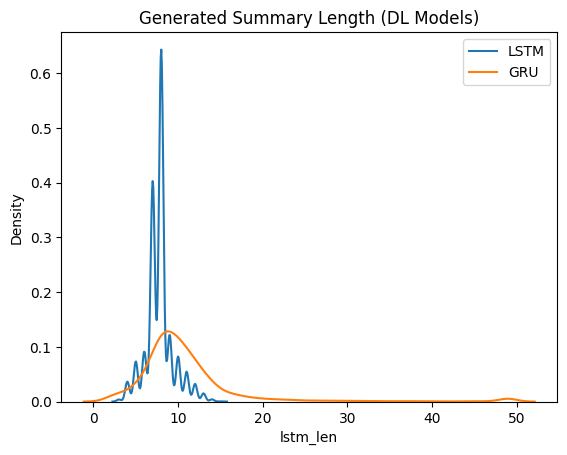

In [3]:
# Output Length Distribution

df_dl["lstm_len"] = df_dl["lstm_summary"].apply(lambda x: len(str(x).split()))
df_dl["gru_len"] = df_dl["gru_summary"].apply(lambda x: len(str(x).split()))

import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df_dl["lstm_len"], label="LSTM")
sns.kdeplot(df_dl["gru_len"], label="GRU")
plt.title("Generated Summary Length (DL Models)")
plt.legend()
plt.show()

In [4]:
# Repetition Analysis

def repetition_score(text):
    words = str(text).split()
    return len(words) - len(set(words))

df_dl["lstm_repetition"] = df_dl["lstm_summary"].apply(repetition_score)
df_dl["gru_repetition"] = df_dl["gru_summary"].apply(repetition_score)

print("LSTM repetition avg:", df_dl["lstm_repetition"].mean())
print("GRU repetition avg:", df_dl["gru_repetition"].mean())

LSTM repetition avg: 2.7297
GRU repetition avg: 2.5488


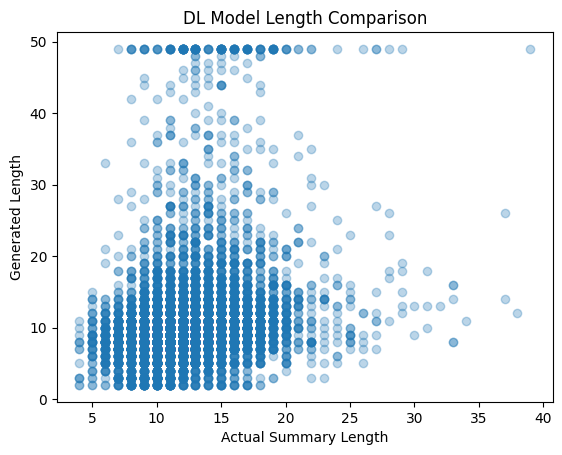

In [5]:
# Compare Output vs Target Length

df_dl["target_len"] = df_dl["summary"].apply(lambda x: len(str(x).split()))

plt.scatter(df_dl["target_len"], df_dl["gru_len"], alpha=0.3)
plt.xlabel("Actual Summary Length")
plt.ylabel("Generated Length")
plt.title("DL Model Length Comparison")
plt.show()

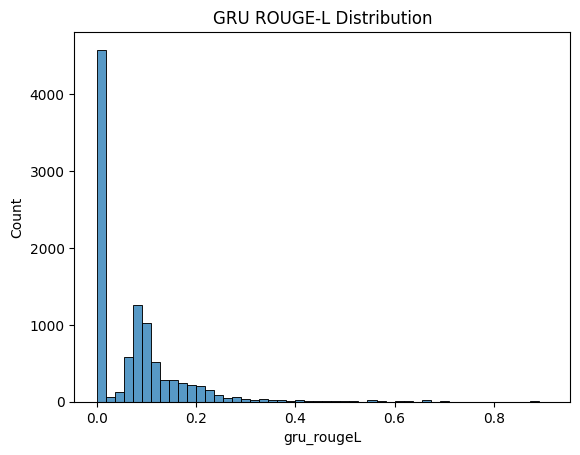

In [6]:
# ROUGE Distribution
# Compute row-level ROUGE for GRU
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

df_dl["gru_rougeL"] = df_dl.apply(
    lambda x: scorer.score(x["summary"], x["gru_summary"])["rougeL"].fmeasure
    if isinstance(x["summary"], str) and isinstance(x["gru_summary"], str) else 0,
    axis=1
)

sns.histplot(df_dl["gru_rougeL"], bins=50)
plt.title("GRU ROUGE-L Distribution")
plt.show()